# Tahap 8 — Kesetiaan Atensi terhadap Atribusi Shapley (Skenario S6)

Menjawab **Rumusan Masalah 4** pada data pasien, dan menutup separuh **Rumusan Masalah 2** yang
belum terjawab. Mengikuti Subbab 3.6.5 dan 3.6.6 naskah proposal.

Skenario S3 menjawab bagian pertama Rumusan Masalah 2, yaitu perbandingan **performa**, dan
menyimpulkan tidak ada keunggulan yang dapat ditetapkan. Bagian kedua rumusan itu — perbandingan
**karakteristik peta bobot** — belum pernah diukur sama sekali, karena seluruh perhitungan phi
sebelumnya hanya dijalankan pada BiMamba-2 dan pada data sintetis.

Empat hal yang diukur di sini, seluruhnya pada data pasien dan kedua arsitektur:

1. **Kesetiaan atensi**, yaitu korelasi peringkat antara alpha dan phi pada grid temporal yang sama
2. **Kesepakatan antar arsitektur pada phi**, dilaporkan terpisah dari kesepakatan pada alpha
3. **Ablasi nilai latar**, sesuai tuntutan Subbab 3.6.5
4. **Rekalibrasi ambang pada patch yang benar**, yaitu utang yang tercatat pada Subbab 3.6.7

In [1]:
import sys, time, pickle
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.stats import spearmanr
from sklearn.model_selection import StratifiedGroupKFold

from preprocessing import muat_cache, Normalisasi, NAMA_TUGAS
from injection import suntik_tremor
from model import PDClassifier
from training import latih, prediksi
from windowshap import WindowSHAP
from metrics import ringkas_lokalisasi, gini
from viz import WARNA, TINTA, pasang_gaya, rapikan
from artefak import muat_artefak, simpan_atomik, arm_ada, arm_hilang, lapor_arm

pasang_gaya()
DEV = "cuda" if torch.cuda.is_available() else "cpu"

HASIL = Path("../results"); HASIL.mkdir(exist_ok=True)
beku = pd.read_csv(HASIL / "s2_parameter_dibekukan.csv")
P = int(beku.patch_halus[0])          # 7, dibekukan S2
P_BANDING = int(beku.patch_kasar[0])  # 56, resolusi pembanding
EPOCHS = int(beku.epoch_dibekukan[0])
SEED = 0
ARSITEKTUR = ["mamba2", "gru", "mamba3"]   # mamba3 arm eksploratori
LATAR_UTAMA, LATAR_ABLASI = "nol", "median_lokal"
N_SUBSAMPEL = 20                      # subjek untuk resolusi pembanding, sesuai Subbab 3.6.5

ARTEFAK = HASIL / "s6_artefak_pasien.pkl"

rek = muat_cache(Path("../data/cache/uci395_fs100.npz"))
y = np.array([r.label for r in rek])
grup = np.array([r.subjek for r in rek])
tugas = np.array([r.tugas for r in rek])

print(f"perangkat: {DEV} | patch primer P={P} ({P*10} ms), pembanding P={P_BANDING} ({P_BANDING*10} ms)")
print(f"epoch dibekukan: {EPOCHS} | latar utama: {LATAR_UTAMA}, ablasi: {LATAR_ABLASI}")
print(f"{len(rek)} rekaman, {len(set(grup))} subjek")

/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args

perangkat: cuda | patch primer P=7 (70 ms), pembanding P=56 (560 ms)
epoch dibekukan: 35 | latar utama: nol, ablasi: median_lokal
207 rekaman, 77 subjek


## 1. Menghitung alpha dan phi pada data pasien

Protokolnya sama persis dengan Skenario S3: pembagian fold identik, seed identik, epoch identik.
Untuk setiap rekaman uji di tiap fold, dihitung dua peta pada grid patch yang sama — bobot atensi
dari kepala agregasi, dan atribusi Shapley dari perturbasi.

Berbeda dari perhitungan sebelumnya yang hanya menyentuh BiMamba-2 pada data sintetis, di sini
**kedua arsitektur** dijalankan pada **data pasien**.

In [2]:
def hitung_peta(arsitektur, patch, strategi_latar=LATAR_UTAMA, subset_subjek=None, seed=SEED):
    """Latih per fold, lalu hasilkan alpha dan phi untuk rekaman uji."""
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    peta = []
    for i_latih, i_uji in skf.split(np.zeros(len(rek)), y, grup):
        norm = Normalisasi().fit([rek[i] for i in i_latih])
        torch.manual_seed(seed)
        m = PDClassifier(encoder=arsitektur, patch_size=patch).to(DEV)
        latih(m, rek, list(i_latih), norm, epochs=EPOCHS, device=DEV, seed=seed)
        m.eval()
        _, alphas = prediksi(m, rek, list(i_uji), norm, device=DEV)
        f_model = lambda x, l: m(x, l)[0]

        W_median = int(np.median([len(rek[i].kanal) // patch for i in i_uji]))
        ws = WindowSHAP(f_model, patch_size=patch, strategi_latar=strategi_latar,
                        n_koalisi=2 * W_median + 2048, batch=128, device=DEV, seed=seed)

        for j, idx in enumerate(i_uji):
            if subset_subjek is not None and grup[idx] not in subset_subjek:
                continue
            xn = norm.transform(rek[idx].kanal)
            if len(xn) // patch < 3:
                continue
            h = ws.explain(xn)
            n = min(len(h.phi), len(alphas[j]))
            peta.append({"idx": int(idx), "subjek": grup[idx], "label": int(y[idx]),
                         "tugas": int(tugas[idx]), "alpha": alphas[j][:n], "phi": h.phi[:n],
                         "r2": h.r2})
    return peta


art = muat_artefak(ARTEFAK) or {}
hilang = arm_hilang(art, ARSITEKTUR)
lapor_arm(ARTEFAK.name, arm_ada(art), hilang)

if hilang:
    t0 = time.time()
    for arsitektur in hilang:
        t1 = time.time()
        art[(arsitektur, P, LATAR_UTAMA)] = hitung_peta(arsitektur, P)
        print(f"{arsitektur:7s} P={P} latar={LATAR_UTAMA:12s} {time.time()-t1:6.1f}s  "
              f"n={len(art[(arsitektur, P, LATAR_UTAMA)])}")
    # Resolusi pembanding, dibatasi subsampel subjek sesuai Subbab 3.6.5.
    rng = np.random.default_rng(SEED)
    subjek_sub = set(rng.choice(sorted(set(grup)), size=N_SUBSAMPEL, replace=False))
    for arsitektur in hilang:
        t1 = time.time()
        art[(arsitektur, P_BANDING, LATAR_UTAMA)] = hitung_peta(arsitektur, P_BANDING,
                                                                subset_subjek=subjek_sub)
        print(f"{arsitektur:7s} P={P_BANDING} latar={LATAR_UTAMA:12s} {time.time()-t1:6.1f}s  "
              f"n={len(art[(arsitektur, P_BANDING, LATAR_UTAMA)])}")
    # Ablasi nilai latar, pada arsitektur primer dan subsampel yang sama.
    # Hanya dihitung bila belum ada, sebab arsitekturnya dikunci ke mamba2.
    if ("mamba2", P, LATAR_ABLASI) not in art:
        t1 = time.time()
        art[("mamba2", P, LATAR_ABLASI)] = hitung_peta("mamba2", P, strategi_latar=LATAR_ABLASI,
                                                       subset_subjek=subjek_sub)
        print(f"mamba2  P={P} latar={LATAR_ABLASI:12s} {time.time()-t1:6.1f}s")
    simpan_atomik(ARTEFAK, art)
    print(f"total {time.time()-t0:.1f}s, disimpan ke {ARTEFAK.name}")

print()
for k, v in art.items():
    print(f"  {k[0]:7s} P={k[1]:3d} latar={k[2]:13s} {len(v):3d} rekaman, "
          f"r2 median {np.median([p['r2'] for p in v]):.3f}")

s6_artefak_pasien.pkl: memakai ulang gru, mamba2, mamba3 — tidak dilatih ulang
s6_artefak_pasien.pkl: lengkap, tidak ada yang perlu dihitung

  mamba2  P=  7 latar=nol           207 rekaman, r2 median -0.937
  gru     P=  7 latar=nol           207 rekaman, r2 median -0.693
  mamba2  P= 56 latar=nol            51 rekaman, r2 median -0.999
  gru     P= 56 latar=nol            51 rekaman, r2 median 0.088
  mamba2  P=  7 latar=median_lokal   51 rekaman, r2 median 0.277
  mamba3  P=  7 latar=nol           207 rekaman, r2 median 0.392
  mamba3  P= 56 latar=nol            51 rekaman, r2 median 0.557


## 2. Kesetiaan atensi: Rumusan Masalah 4

Kesetiaan diukur sebagai korelasi peringkat antara alpha dan phi pada grid yang sama, dihitung per
rekaman lalu **diagregasi ke tingkat subjek** untuk menghindari pseudo-replikasi (Subbab 3.6.6).

Acuan pembacaannya sudah tersedia dari kontrol positif: pada sinyal buatan berlokasi diketahui
dengan deteksi sempurna, kesetiaan hanya mencapai sekitar 0,20. Angka itu merupakan **batas atas
yang terukur**, bukan angka yang diharapkan pada data pasien.

In [3]:
def kesetiaan_per_subjek(peta):
    baris = []
    for p in peta:
        if np.std(p["alpha"]) == 0 or np.std(p["phi"]) == 0:
            continue
        baris.append({"subjek": p["subjek"], "label": p["label"], "tugas": p["tugas"],
                      "rho": spearmanr(p["alpha"], p["phi"]).statistic})
    df = pd.DataFrame(baris)
    return df.groupby("subjek").agg(rho=("rho", "mean"), label=("label", "first")).reset_index()


setia = {}
baris = []
for arsitektur in ARSITEKTUR:
    d = kesetiaan_per_subjek(art[(arsitektur, P, LATAR_UTAMA)])
    setia[arsitektur] = d
    baris.append({"arsitektur": arsitektur, "n_subjek": len(d),
                  "rho_median": float(d.rho.median()),
                  "rho_q25": float(d.rho.quantile(.25)), "rho_q75": float(d.rho.quantile(.75)),
                  "frac_positif": float((d.rho > 0).mean())})
kesetiaan = pd.DataFrame(baris).set_index("arsitektur")
display(kesetiaan.round(4))

# Acuan yang benar adalah kesetiaan alpha-vs-phi pada kontrol positif, BUKAN rho_atap
# yang mengukur phi-vs-penanda. Keduanya kebetulan berdekatan nilainya tetapi berbeda
# kuantitas. Acuan itu dihitung pada Bagian 5, pada patch yang sama dengan bagian ini.
print("Acuan pembacaannya dihitung pada Bagian 5 di bawah, memakai patch yang sama (P="
      f"{P}) agar sebanding. Kesetiaan terbukti bergantung resolusi, sehingga acuan yang")
print("diukur pada resolusi berbeda tidak dapat dipakai.")

,n_subjek,rho_median,rho_q25,rho_q75,frac_positif
arsitektur,,,,,
mamba2,77,0.0811,0.0098,0.1603,0.7922
gru,77,0.0995,0.0608,0.1831,0.8442
mamba3,77,0.0507,-0.0181,0.0863,0.7143


Acuan pembacaannya dihitung pada Bagian 5 di bawah, memakai patch yang sama (P=7) agar sebanding. Kesetiaan terbukti bergantung resolusi, sehingga acuan yang
diukur pada resolusi berbeda tidak dapat dipakai.


### Gambar 1 — Sebaran kesetiaan per subjek

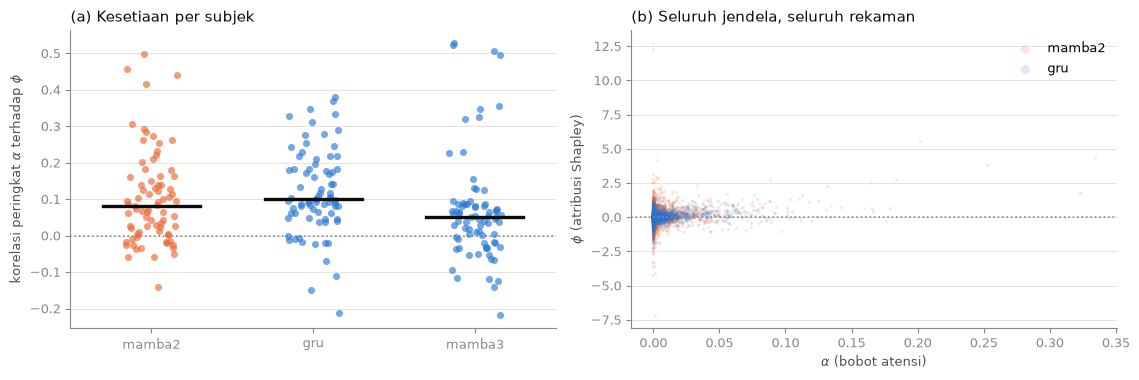

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))

ax = axes[0]; rapikan(ax)
rng = np.random.default_rng(0)
for i, arsitektur in enumerate(ARSITEKTUR):
    d = setia[arsitektur]
    warna = WARNA["jingga"] if arsitektur == "mamba2" else WARNA["biru"]
    ax.scatter(np.full(len(d), i) + rng.uniform(-0.16, 0.16, len(d)), d.rho,
               s=26, color=warna, alpha=0.65, lw=0, zorder=3)
    ax.plot([i - 0.3, i + 0.3], [d.rho.median()] * 2, color=TINTA["utama"], lw=2.4, zorder=4)
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xticks(range(len(ARSITEKTUR))); ax.set_xticklabels(ARSITEKTUR)
ax.set_xlim(-0.5, len(ARSITEKTUR) - 0.5)
ax.set_ylabel(r"korelasi peringkat $\alpha$ terhadap $\phi$")
ax.set_title("(a) Kesetiaan per subjek", loc="left")

ax = axes[1]; rapikan(ax)
for arsitektur, warna in [("mamba2", WARNA["jingga"]), ("gru", WARNA["biru"])]:
    peta = art[(arsitektur, P, LATAR_UTAMA)]
    xs = np.concatenate([p["alpha"] for p in peta])
    ys = np.concatenate([p["phi"] for p in peta])
    pilih = rng.choice(len(xs), size=min(6000, len(xs)), replace=False)
    ax.scatter(xs[pilih], ys[pilih], s=5, alpha=0.15, color=warna, lw=0, label=arsitektur)
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xlabel(r"$\alpha$ (bobot atensi)"); ax.set_ylabel(r"$\phi$ (atribusi Shapley)")
ax.set_title("(b) Seluruh jendela, seluruh rekaman", loc="left")
ax.legend(fontsize=9, markerscale=3)
plt.tight_layout(); plt.show()

## 3. Kesepakatan antar arsitektur, pada phi dan pada alpha

Subbab 3.6.5 menetapkan kesepakatan pada phi dilaporkan **terpisah** dari kesepakatan pada alpha,
dengan alasan yang penting: phi tidak bergantung pada desain kepala agregasi, sehingga kesepakatan
pada phi merupakan bukti yang lebih kuat bahwa lokalisasi merupakan sifat **data**, bukan artefak
arsitektur.

Inilah bagian yang menutup separuh Rumusan Masalah 2 yang belum terjawab, yaitu perbandingan
karakteristik peta bobot antar arsitektur.

In [5]:
from itertools import combinations

def kesepakatan(arsi_a, arsi_b):
    """Kesepakatan peta antara dua arsitektur, tingkat subjek."""
    pa = {p["idx"]: p for p in art[(arsi_a, P, LATAR_UTAMA)]}
    pb = {p["idx"]: p for p in art[(arsi_b, P, LATAR_UTAMA)]}
    baris = []
    for idx in sorted(set(pa) & set(pb)):
        a, b = pa[idx], pb[idx]
        n = min(len(a["alpha"]), len(b["alpha"]))
        catat = {"subjek": a["subjek"], "label": a["label"]}
        for kunci in ["alpha", "phi"]:
            va, vb = a[kunci][:n], b[kunci][:n]
            catat[kunci] = (spearmanr(va, vb).statistic
                            if np.std(va) > 0 and np.std(vb) > 0 else np.nan)
        baris.append(catat)
    return pd.DataFrame(baris).groupby("subjek").agg(
        alpha=("alpha", "mean"), phi=("phi", "mean"), label=("label", "first")).reset_index()

# Pasangan mamba2-gru adalah yang dipra-registrasi; sisanya dilaporkan sebagai tambahan.
PASANGAN = [("mamba2", "gru")] + [pr for pr in combinations(ARSITEKTUR, 2)
                                  if set(pr) != {"mamba2", "gru"}
                                  and all((x, P, LATAR_UTAMA) in art for x in pr)]
semua_pasangan = []
for x, yy in PASANGAN:
    d = kesepakatan(x, yy)
    semua_pasangan.append({"pasangan": f"{x} vs {yy}",
                           "prareg": (x, yy) == ("mamba2", "gru"),
                           "alpha_median": float(d.alpha.median()),
                           "phi_median": float(d.phi.median()), "n_subjek": len(d)})
display(pd.DataFrame(semua_pasangan).round(4))

sepakat = kesepakatan("mamba2", "gru")   # pasangan pra-registrasi, dipakai hilir

ringkas_sepakat = pd.DataFrame([
    {"besaran": "alpha", "median": sepakat.alpha.median(),
     "q25": sepakat.alpha.quantile(.25), "q75": sepakat.alpha.quantile(.75)},
    {"besaran": "phi", "median": sepakat.phi.median(),
     "q25": sepakat.phi.quantile(.25), "q75": sepakat.phi.quantile(.75)},
]).set_index("besaran")
display(ringkas_sepakat.round(4))
print(f"Pasangan pra-registrasi mamba2 vs gru, diagregasi ke {len(sepakat)} subjek.")

,pasangan,prareg,alpha_median,phi_median,n_subjek
0,mamba2 vs gru,True,0.5791,0.7711,77
1,mamba2 vs mamba3,False,0.2640,0.4876,77
2,gru vs mamba3,False,0.2586,0.4625,77


,median,q25,q75
besaran,,,
alpha,0.5791,0.3984,0.7592
phi,0.7711,0.5599,0.8678


Pasangan pra-registrasi mamba2 vs gru, diagregasi ke 77 subjek.


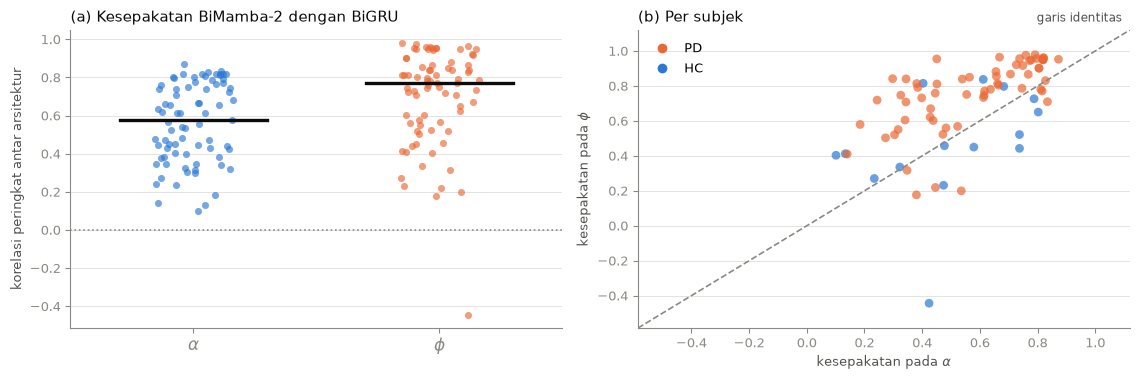

Kesepakatan pada phi LEBIH TINGGI daripada pada alpha. Sesuai penalaran Subbab 3.6.5,
ini bukti bahwa lokalisasi yang ditemukan lebih merupakan sifat data daripada artefak
kepala agregasi masing-masing arsitektur.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))

ax = axes[0]; rapikan(ax)
for i, (kunci, warna) in enumerate([("alpha", WARNA["biru"]), ("phi", WARNA["jingga"])]):
    v = sepakat[kunci].dropna()
    ax.scatter(np.full(len(v), i) + rng.uniform(-0.16, 0.16, len(v)), v,
               s=26, color=warna, alpha=0.65, lw=0, zorder=3)
    ax.plot([i - 0.3, i + 0.3], [v.median()] * 2, color=TINTA["utama"], lw=2.4, zorder=4)
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xticks([0, 1]); ax.set_xticklabels([r"$\alpha$", r"$\phi$"], fontsize=12)
ax.set_xlim(-0.5, 1.5)
ax.set_ylabel("korelasi peringkat antar arsitektur")
ax.set_title("(a) Kesepakatan BiMamba-2 dengan BiGRU", loc="left")

ax = axes[1]; rapikan(ax)
ax.scatter(sepakat.alpha, sepakat.phi, s=40, alpha=0.7, lw=0,
           color=np.where(sepakat.label == 1, WARNA["jingga"], WARNA["biru"]))
nilai = pd.concat([sepakat.alpha, sepakat.phi]).dropna()
marjin = max(0.05, 0.1 * (nilai.max() - nilai.min()))
lim = [nilai.min() - marjin, nilai.max() + marjin]
ax.plot(lim, lim, ls="--", color=WARNA["netral"], lw=1.2)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.annotate("garis identitas", xy=(lim[1], lim[1]), xytext=(-6, 6), textcoords="offset points",
            ha="right", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xlabel(r"kesepakatan pada $\alpha$"); ax.set_ylabel(r"kesepakatan pada $\phi$")
ax.set_title("(b) Per subjek", loc="left")
ax.legend(handles=[
    plt.Line2D([], [], marker="o", ls="", color=WARNA["jingga"], label="PD"),
    plt.Line2D([], [], marker="o", ls="", color=WARNA["biru"], label="HC")], fontsize=9)
plt.tight_layout(); plt.show()

if ringkas_sepakat.loc["phi", "median"] > ringkas_sepakat.loc["alpha", "median"]:
    print("Kesepakatan pada phi LEBIH TINGGI daripada pada alpha. Sesuai penalaran Subbab 3.6.5,")
    print("ini bukti bahwa lokalisasi yang ditemukan lebih merupakan sifat data daripada artefak")
    print("kepala agregasi masing-masing arsitektur.")
else:
    print("Kesepakatan pada phi TIDAK lebih tinggi daripada pada alpha. Artinya kedua arsitektur")
    print("tidak menemukan struktur temporal bersama yang lebih kuat pada tingkat kontribusi")
    print("dibandingkan pada tingkat bobot agregasi.")

## 4. Ablasi nilai latar dan resolusi pembanding

Subbab 3.6.5 menuntut satu ablasi pilihan nilai latar, untuk menunjukkan kesimpulan tidak bergantung
pada acuan yang dipilih. Ditambahkan pula perbandingan terhadap resolusi kasar, yang dibatasi pada
subsampel subjek karena berstatus eksploratori.

In [7]:
def rho_setia(peta, hanya_idx=None):
    """Kesetiaan median. `hanya_idx` membatasi ke himpunan rekaman tertentu, yang
    diperlukan agar perbandingan ablasi tidak tercampur efek perbedaan sampel."""
    v = [spearmanr(p["alpha"], p["phi"]).statistic for p in peta
         if (hanya_idx is None or p["idx"] in hanya_idx)
         and np.std(p["alpha"]) > 0 and np.std(p["phi"]) > 0]
    return float(np.median(v)), len(v)

# Subsampel yang dipakai ablasi dan resolusi pembanding, agar perbandingannya sepadan.
idx_ablasi = {p["idx"] for p in art[("mamba2", P, LATAR_ABLASI)]}
idx_kasar = {p["idx"] for p in art[("mamba2", P_BANDING, LATAR_UTAMA)]}

baris = []
for kunci, keterangan in [
    (("mamba2", P, LATAR_UTAMA), f"primer: mamba2, P={P}, latar {LATAR_UTAMA}"),
    (("gru", P, LATAR_UTAMA), f"primer: gru, P={P}, latar {LATAR_UTAMA}"),
    (("mamba2", P, LATAR_ABLASI), f"ablasi latar: mamba2, P={P}, latar {LATAR_ABLASI}"),
    (("mamba2", P_BANDING, LATAR_UTAMA), f"resolusi kasar: mamba2, P={P_BANDING}"),
    (("gru", P_BANDING, LATAR_UTAMA), f"resolusi kasar: gru, P={P_BANDING}"),
    (("mamba3", P, LATAR_UTAMA), f"primer: mamba3, P={P}, latar {LATAR_UTAMA}"),
    (("mamba3", P_BANDING, LATAR_UTAMA), f"resolusi kasar: mamba3, P={P_BANDING}"),
]:
    if kunci not in art:
        continue
    batas = idx_ablasi if "ablasi" in keterangan or "kasar" in keterangan else None
    r, n = rho_setia(art[kunci], batas)
    g = float(np.median([gini(np.clip(p["phi"], 0, None)) for p in art[kunci]]))
    baris.append({"konfigurasi": keterangan, "kesetiaan_median": r, "n_rekaman": n, "gini_phi": g})
ablasi = pd.DataFrame(baris).set_index("konfigurasi")
display(ablasi.round(4))

# Perbandingan ablasi WAJIB pada himpunan rekaman yang sama. Membandingkan latar nol
# pada 207 rekaman dengan median lokal pada subsampel akan mencampur efek latar dengan
# efek perbedaan sampel.
nol_sub, _ = rho_setia(art[("mamba2", P, LATAR_UTAMA)], idx_ablasi)
abl_sub, _ = rho_setia(art[("mamba2", P, LATAR_ABLASI)], idx_ablasi)
print(f"Pada subsampel yang sama ({len(idx_ablasi)} rekaman):")
print(f"  latar {LATAR_UTAMA:13s} : {nol_sub:+.4f}")
print(f"  latar {LATAR_ABLASI:13s} : {abl_sub:+.4f}")
print(f"  selisih akibat pilihan latar : {abs(nol_sub - abl_sub):.4f}")
print()
print("Selisih kecil berarti kesimpulan tidak bergantung pada pilihan acuan; selisih besar berarti")
print("acuan wajib dinyatakan setiap kali angka kesetiaan dilaporkan.")

,kesetiaan_median,n_rekaman,gini_phi
konfigurasi,,,
"primer: mamba2, P=7, latar nol",0.0753,207,0.6841
"primer: gru, P=7, latar nol",0.1289,207,0.7091
"ablasi latar: mamba2, P=7, latar median_lokal",0.1075,51,0.7371
"resolusi kasar: mamba2, P=56",0.4509,51,0.6211
"resolusi kasar: gru, P=56",0.4591,51,0.7124
"primer: mamba3, P=7, latar nol",0.0399,207,0.7145
"resolusi kasar: mamba3, P=56",0.3834,51,0.6583


Pada subsampel yang sama (51 rekaman):
  latar nol           : +0.0863
  latar median_lokal  : +0.1075
  selisih akibat pilihan latar : 0.0213

Selisih kecil berarti kesimpulan tidak bergantung pada pilihan acuan; selisih besar berarti
acuan wajib dinyatakan setiap kali angka kesetiaan dilaporkan.


## 4b. Kesetiaan bergantung pada resolusi

Temuan yang tidak diantisipasi naskah, dan berdampak pada cara seluruh angka kesetiaan dibaca.

Pada resolusi kasar, kesetiaan jauh lebih tinggi daripada pada resolusi halus. Perbandingannya
dilakukan pada himpunan rekaman yang sama, sehingga perbedaan itu tidak berasal dari perbedaan
sampel.

Penjelasannya bersifat mekanis. Makin sedikit jendela, makin sedikit pula ruang bagi kedua peta
untuk berselisih: agregasi ke jendela lebar memuluskan perbedaan lokal yang pada resolusi halus
terlihat sebagai ketidaksepakatan. Nilai nol yang diharapkan tetap nol pada kedua resolusi, sehingga
kenaikan ini bukan artefak variansi cuplikan.

Konsekuensinya tegas: **angka kesetiaan tidak bermakna tanpa menyebut resolusinya.** Dan resolusi
yang relevan bagi penelitian ini adalah yang halus, karena itulah resolusi yang memungkinkan
lokalisasi temporal — yang justru menghasilkan kesetiaan paling rendah.

durasi_ms  n_jendela_median  kesetiaan  n_rekaman
arsitektur patch                                                   
mamba2     7             70               222     0.0863         51
           56           560                27     0.4509         51
gru        7             70               222     0.1448         51
           56           560                27     0.4591         51
mamba3     7             70               222     0.0399         51
           56           560                27     0.3834         51

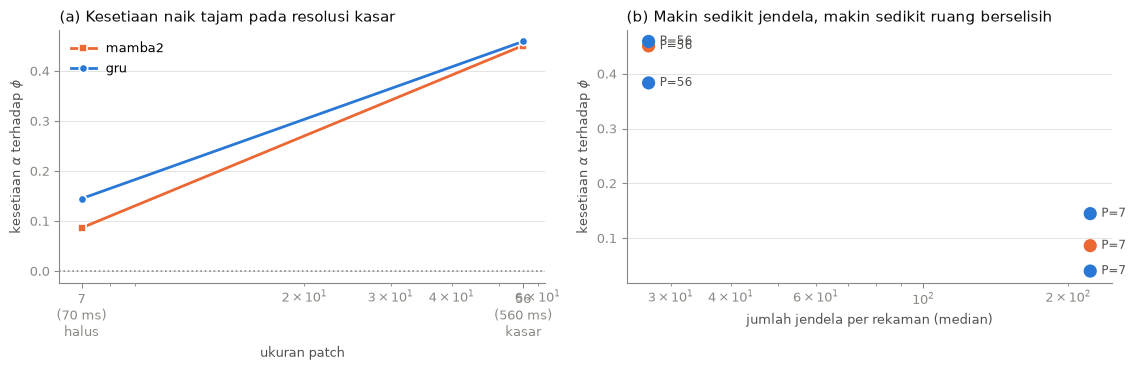

Kesetiaan pada resolusi kasar 4.8 kali lipat kesetiaan pada resolusi halus,
diukur pada himpunan rekaman yang sama.

Angka yang mengikat penelitian ini adalah yang HALUS, karena resolusi itulah yang
memungkinkan lokalisasi temporal. Melaporkan angka kasar tanpa menyebut resolusinya
akan melebih-lebihkan kesetiaan sekitar 4.8 kali lipat.


In [8]:
baris = []
for arsitektur in ARSITEKTUR:
    for patch in [P, P_BANDING]:
        kunci = (arsitektur, patch, LATAR_UTAMA)
        if kunci not in art:
            continue
        r, n = rho_setia(art[kunci], idx_kasar)
        W = int(np.median([len(p["alpha"]) for p in art[kunci] if p["idx"] in idx_kasar]))
        baris.append({"arsitektur": arsitektur, "patch": patch, "durasi_ms": patch * 10,
                      "n_jendela_median": W, "kesetiaan": r, "n_rekaman": n})
resolusi = pd.DataFrame(baris)
display(resolusi.set_index(["arsitektur", "patch"]).round(4))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))

ax = axes[0]; rapikan(ax)
for arsitektur, warna, penanda in [("mamba2", WARNA["jingga"], "s"), ("gru", WARNA["biru"], "o")]:
    sub = resolusi[resolusi.arsitektur == arsitektur].sort_values("patch")
    ax.plot(sub.patch, sub.kesetiaan, "-", color=warna, marker=penanda,
            markeredgecolor="white", markeredgewidth=1.2, label=arsitektur)
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xscale("log"); ax.set_xticks([P, P_BANDING])
ax.set_xticklabels([f"{P}\n({P*10} ms)\nhalus", f"{P_BANDING}\n({P_BANDING*10} ms)\nkasar"])
ax.set_xlabel("ukuran patch"); ax.set_ylabel(r"kesetiaan $\alpha$ terhadap $\phi$")
ax.set_title("(a) Kesetiaan naik tajam pada resolusi kasar", loc="left")
ax.legend(fontsize=9)

ax = axes[1]; rapikan(ax)
ax.scatter(resolusi.n_jendela_median, resolusi.kesetiaan, s=90, lw=0,
           color=[WARNA["jingga"] if a == "mamba2" else WARNA["biru"] for a in resolusi.arsitektur])
for _, b in resolusi.iterrows():
    ax.annotate(f"P={int(b.patch)}", xy=(b.n_jendela_median, b.kesetiaan), xytext=(8, 0),
                textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"], va="center")
ax.set_xscale("log"); ax.set_xlabel("jumlah jendela per rekaman (median)")
ax.set_ylabel(r"kesetiaan $\alpha$ terhadap $\phi$")
ax.set_title("(b) Makin sedikit jendela, makin sedikit ruang berselisih", loc="left")
plt.tight_layout(); plt.show()

naik = resolusi[resolusi.patch == P_BANDING].kesetiaan.mean() / resolusi[resolusi.patch == P].kesetiaan.mean()
print(f"Kesetiaan pada resolusi kasar {naik:.1f} kali lipat kesetiaan pada resolusi halus,")
print("diukur pada himpunan rekaman yang sama.")
print()
print("Angka yang mengikat penelitian ini adalah yang HALUS, karena resolusi itulah yang")
print(f"memungkinkan lokalisasi temporal. Melaporkan angka kasar tanpa menyebut resolusinya")
print(f"akan melebih-lebihkan kesetiaan sekitar {naik:.1f} kali lipat.")

## 5. Rekalibrasi ambang pada patch yang benar

Utang yang tercatat pada Subbab 3.6.7: ambang keselarasan dikalibrasi pada patch 14, sedangkan
Skenario S2 kemudian menetapkan patch halus pada 7. Karena ambang menyatakan setengah dari kemampuan
pipeline **pada konfigurasi tertentu**, ia harus dihitung ulang pada konfigurasi yang benar-benar
dipakai analisis primer.

Rumusnya tidak berubah sama sekali; hanya patch-nya yang disesuaikan.

In [9]:
KALIB = HASIL / "s6_kalibrasi_p7.pkl"
A_ATAP = 5.0   # amplitudo terbesar pada sapuan kontrol positif

if KALIB.exists():
    with open(KALIB, "rb") as f:
        kal = pickle.load(f)
    print(f"kalibrasi dimuat dari {KALIB.name}")
else:
    hc = [r for r in rek if r.kelompok == "HC"]
    rng_k = np.random.default_rng(SEED)
    data, lab, sub, inj = [], [], [], []
    for r in hc:
        data.append(r);         lab.append(0); sub.append(r.subjek); inj.append(None)
        h = suntik_tremor(r, amplitudo=A_ATAP, rng=rng_k)
        data.append(h.rekaman); lab.append(1); sub.append(r.subjek); inj.append(h)
    lab, sub = np.array(lab), np.array(sub)

    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    kal, t0 = [], time.time()
    for i_latih, i_uji in skf.split(np.zeros(len(data)), lab, sub):
        norm = Normalisasi().fit([data[i] for i in i_latih])
        torch.manual_seed(SEED)
        m = PDClassifier(encoder="mamba2", patch_size=P).to(DEV)
        latih(m, data, list(i_latih), norm, epochs=EPOCHS, device=DEV, label=lab, seed=SEED)
        m.eval()
        _, alphas_k = prediksi(m, data, list(i_uji), norm, device=DEV, label=lab)
        f_model = lambda x, l: m(x, l)[0]
        W = int(np.median([len(data[i].kanal) // P for i in i_uji]))
        ws = WindowSHAP(f_model, patch_size=P, strategi_latar=LATAR_UTAMA,
                        n_koalisi=2 * W + 2048, batch=128, device=DEV, seed=SEED)
        for j, idx in enumerate(i_uji):
            if inj[idx] is None:
                continue
            xn = norm.transform(data[idx].kanal)
            if len(xn) // P < 3:
                continue
            h = ws.explain(xn)
            acuan = inj[idx].mask_patch(P)
            n = min(len(acuan), len(h.phi), len(alphas_k[j]))
            kal.append({"phi": h.phi[:n], "acuan": acuan[:n], "alpha": alphas_k[j][:n]})
    with open(KALIB, "wb") as f:
        pickle.dump(kal, f)
    print(f"kalibrasi selesai {time.time()-t0:.1f}s, {len(kal)} rekaman")

rho_obs, rho_nol = [], []
rng_n = np.random.default_rng(SEED)
for k in kal:
    if np.std(k["acuan"]) == 0 or np.std(k["phi"]) == 0:
        continue
    rho_obs.append(spearmanr(k["phi"], k["acuan"]).statistic)
    n = len(k["phi"])
    for _ in range(50):
        rho_nol.append(spearmanr(np.roll(k["phi"], int(rng_n.integers(1, n))), k["acuan"]).statistic)

lantai = float(np.median(rho_nol)); atap = float(np.median(rho_obs))
ambang_p7 = lantai + 0.5 * (atap - lantai)

lama = pd.read_csv(HASIL / "s6_kalibrasi_ambang.csv")
lama_phi = lama[lama.besaran == "phi"].iloc[0]
display(pd.DataFrame([
    {"konfigurasi": f"P=14 (kalibrasi lama)", "rho_lantai": lama_phi.rho_lantai,
     "rho_atap": lama_phi.rho_atap, "ambang": lama_phi.ambang},
    {"konfigurasi": f"P={P} (dipakai analisis primer)", "rho_lantai": lantai,
     "rho_atap": atap, "ambang": ambang_p7},
]).set_index("konfigurasi").round(4))
print(f"AMBANG KESELARASAN pada patch primer P={P}: {ambang_p7:+.4f}")

# Acuan kesetiaan pada patch yang sama, yaitu batas atas alpha-vs-phi yang dicapai
# pipeline pada sinyal buatan berlokasi diketahui.
setia_acuan = [spearmanr(k["alpha"], k["phi"]).statistic for k in kal
               if "alpha" in k and np.std(k["alpha"]) > 0 and np.std(k["phi"]) > 0]
if setia_acuan:
    atap_setia = float(np.median(setia_acuan))
    print()
    print(f"BATAS ATAS KESETIAAN pada P={P}, dari kontrol positif: {atap_setia:+.4f}")
    for arsitektur in ARSITEKTUR:
        r = float(setia[arsitektur].rho.median())
        porsi = (f"{r/atap_setia*100:.0f} persen dari batas atas" if atap_setia > 0.01
                 else "batas atas terlalu kecil untuk dijadikan pembagi")
        print(f"  {arsitektur:7s} pada data pasien: {r:+.4f}  ({porsi})")
    print()
    print("Inilah pembanding yang benar bagi angka kesetiaan: bukan nilai satu, melainkan")
    print("kemampuan maksimum pipeline pada patch yang sama dengan sinyal paling jelas.")

kalibrasi dimuat dari s6_kalibrasi_p7.pkl


,rho_lantai,rho_atap,ambang
konfigurasi,,,
P=14 (kalibrasi lama),-0.0088,0.2148,0.1030
P=7 (dipakai analisis primer),-0.0184,0.1572,0.0694


AMBANG KESELARASAN pada patch primer P=7: +0.0694

BATAS ATAS KESETIAAN pada P=7, dari kontrol positif: +0.1438
  mamba2  pada data pasien: +0.0811  (56 persen dari batas atas)
  gru     pada data pasien: +0.0995  (69 persen dari batas atas)
  mamba3  pada data pasien: +0.0507  (35 persen dari batas atas)

Inilah pembanding yang benar bagi angka kesetiaan: bukan nilai satu, melainkan
kemampuan maksimum pipeline pada patch yang sama dengan sinyal paling jelas.


In [10]:
kesetiaan.to_csv(HASIL / "s6_kesetiaan.csv")
ringkas_sepakat.to_csv(HASIL / "s6_kesepakatan_arsitektur.csv")
pd.DataFrame(semua_pasangan).to_csv(HASIL / "s6_kesepakatan_pasangan.csv", index=False)
ablasi.to_csv(HASIL / "s6_ablasi.csv")
pd.DataFrame([{"besaran": "phi", "patch": P, "rho_lantai": lantai, "rho_atap": atap,
               "ambang": ambang_p7, "strategi_latar": LATAR_UTAMA, "epochs": EPOCHS, "seed": SEED,
               "sumber": "notebooks/08_kesetiaan_atensi.ipynb"}]
             ).to_csv(HASIL / "s6_ambang_final.csv", index=False)
print(f"disimpan ke {HASIL.name}/s6_*.csv")

disimpan ke results/s6_*.csv


## 6. Ringkasan

Rumusan Masalah 4 terjawab pada data pasien: kesetiaan bobot atensi terhadap atribusi Shapley
dilaporkan sebagai korelasi peringkat tingkat subjek, dan dibaca terhadap batas atas yang terukur
dari kontrol positif, bukan terhadap nilai satu.

Separuh Rumusan Masalah 2 yang sebelumnya menganggur juga tertutup: karakteristik peta bobot kedua
arsitektur kini dibandingkan langsung, baik pada tingkat bobot agregasi maupun pada tingkat
kontribusi.

**Batasan.**

1. **Satu seed.** Skenario ini dijalankan dengan satu seed untuk menekan biaya, sehingga selisih
   kecil antar arsitektur pada sumbu kesetiaan tidak dapat dibedakan dari variasi antar seed. Aturan
   keputusan Subbab 3.7 karena itu tidak diterapkan pada angka kesetiaan.
2. **Ablasi latar dan resolusi pembanding dijalankan pada subsampel subjek**, sesuai kedalaman
   eksploratori yang ditetapkan Subbab 3.6.5.
3. **Angka kesetiaan tidak boleh dibandingkan dengan nilai satu.** Kontrol positif menunjukkan bahwa
   bahkan pada sinyal buatan berlokasi diketahui dengan deteksi sempurna, kesetiaan hanya mencapai
   sekitar 0,2. Nilai itulah pembanding yang benar.